In [5]:
# 1st code:

# IMPORT LIBRARIES

# We import all the tools we need for:
# - Data loading and cleaning (pandas, numpy)
# - Visualisation (matplotlib, seaborn)
# - Machine learning models and evaluation (scikit-learn)
# - Handling class imbalance (imblearn)

import numpy as np                      # numerical operations and arrays
import pandas as pd                     # working with tabular data (DataFrame)
import matplotlib.pyplot as plt         # basic plotting
import seaborn as sns                   # high-level plotting

from sklearn.model_selection import train_test_split    # split data into train and test
from sklearn.preprocessing import StandardScaler        # scale/standardize features
from sklearn.decomposition import PCA                   # Principal Component Analysis (PCA)

from sklearn.metrics import (                          # metrics to judge model performance
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)

from sklearn.linear_model import LogisticRegression     # baseline linear classifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC                             # Support Vector Machine classifier

from imblearn.over_sampling import SMOTE                # oversampling technique for imbalanced data

import warnings
warnings.filterwarnings("ignore")                       # hide non-critical warnings to keep output clean

print("Libraries loaded for the analysis.")

Libraries loaded for the analysis.


In [6]:
# CODE 2: Load your dataset (stroke.csv, parkinson.csv, epilepsy.csv)
# in the same directory or load from a URL.

data = pd.read_csv("parkinsons.csv")

# View the first few rows
data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335


In [7]:
# CODE 3: This step helps you understand what the dataset contains.

print(data.shape)        # Number of rows and columns
print(data.info())       # Data types and missing values
data.describe()          # Summary statistics

# NB
numeric_data = data.select_dtypes(include=['number']) # Numeric data
cat_data = data.select_dtypes(include=['object']) # Categorical data
# numeric_data.T # Transpose

(195, 24)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    

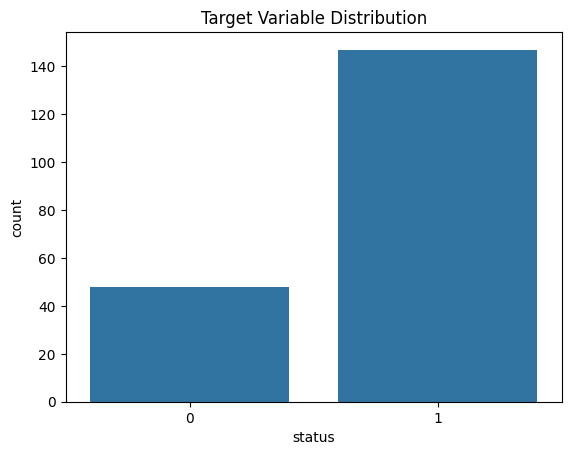

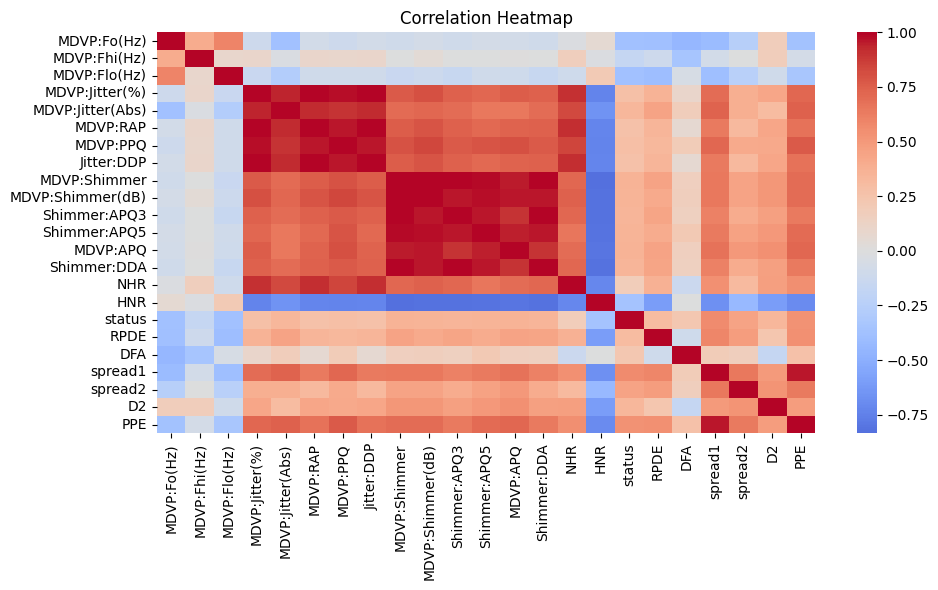

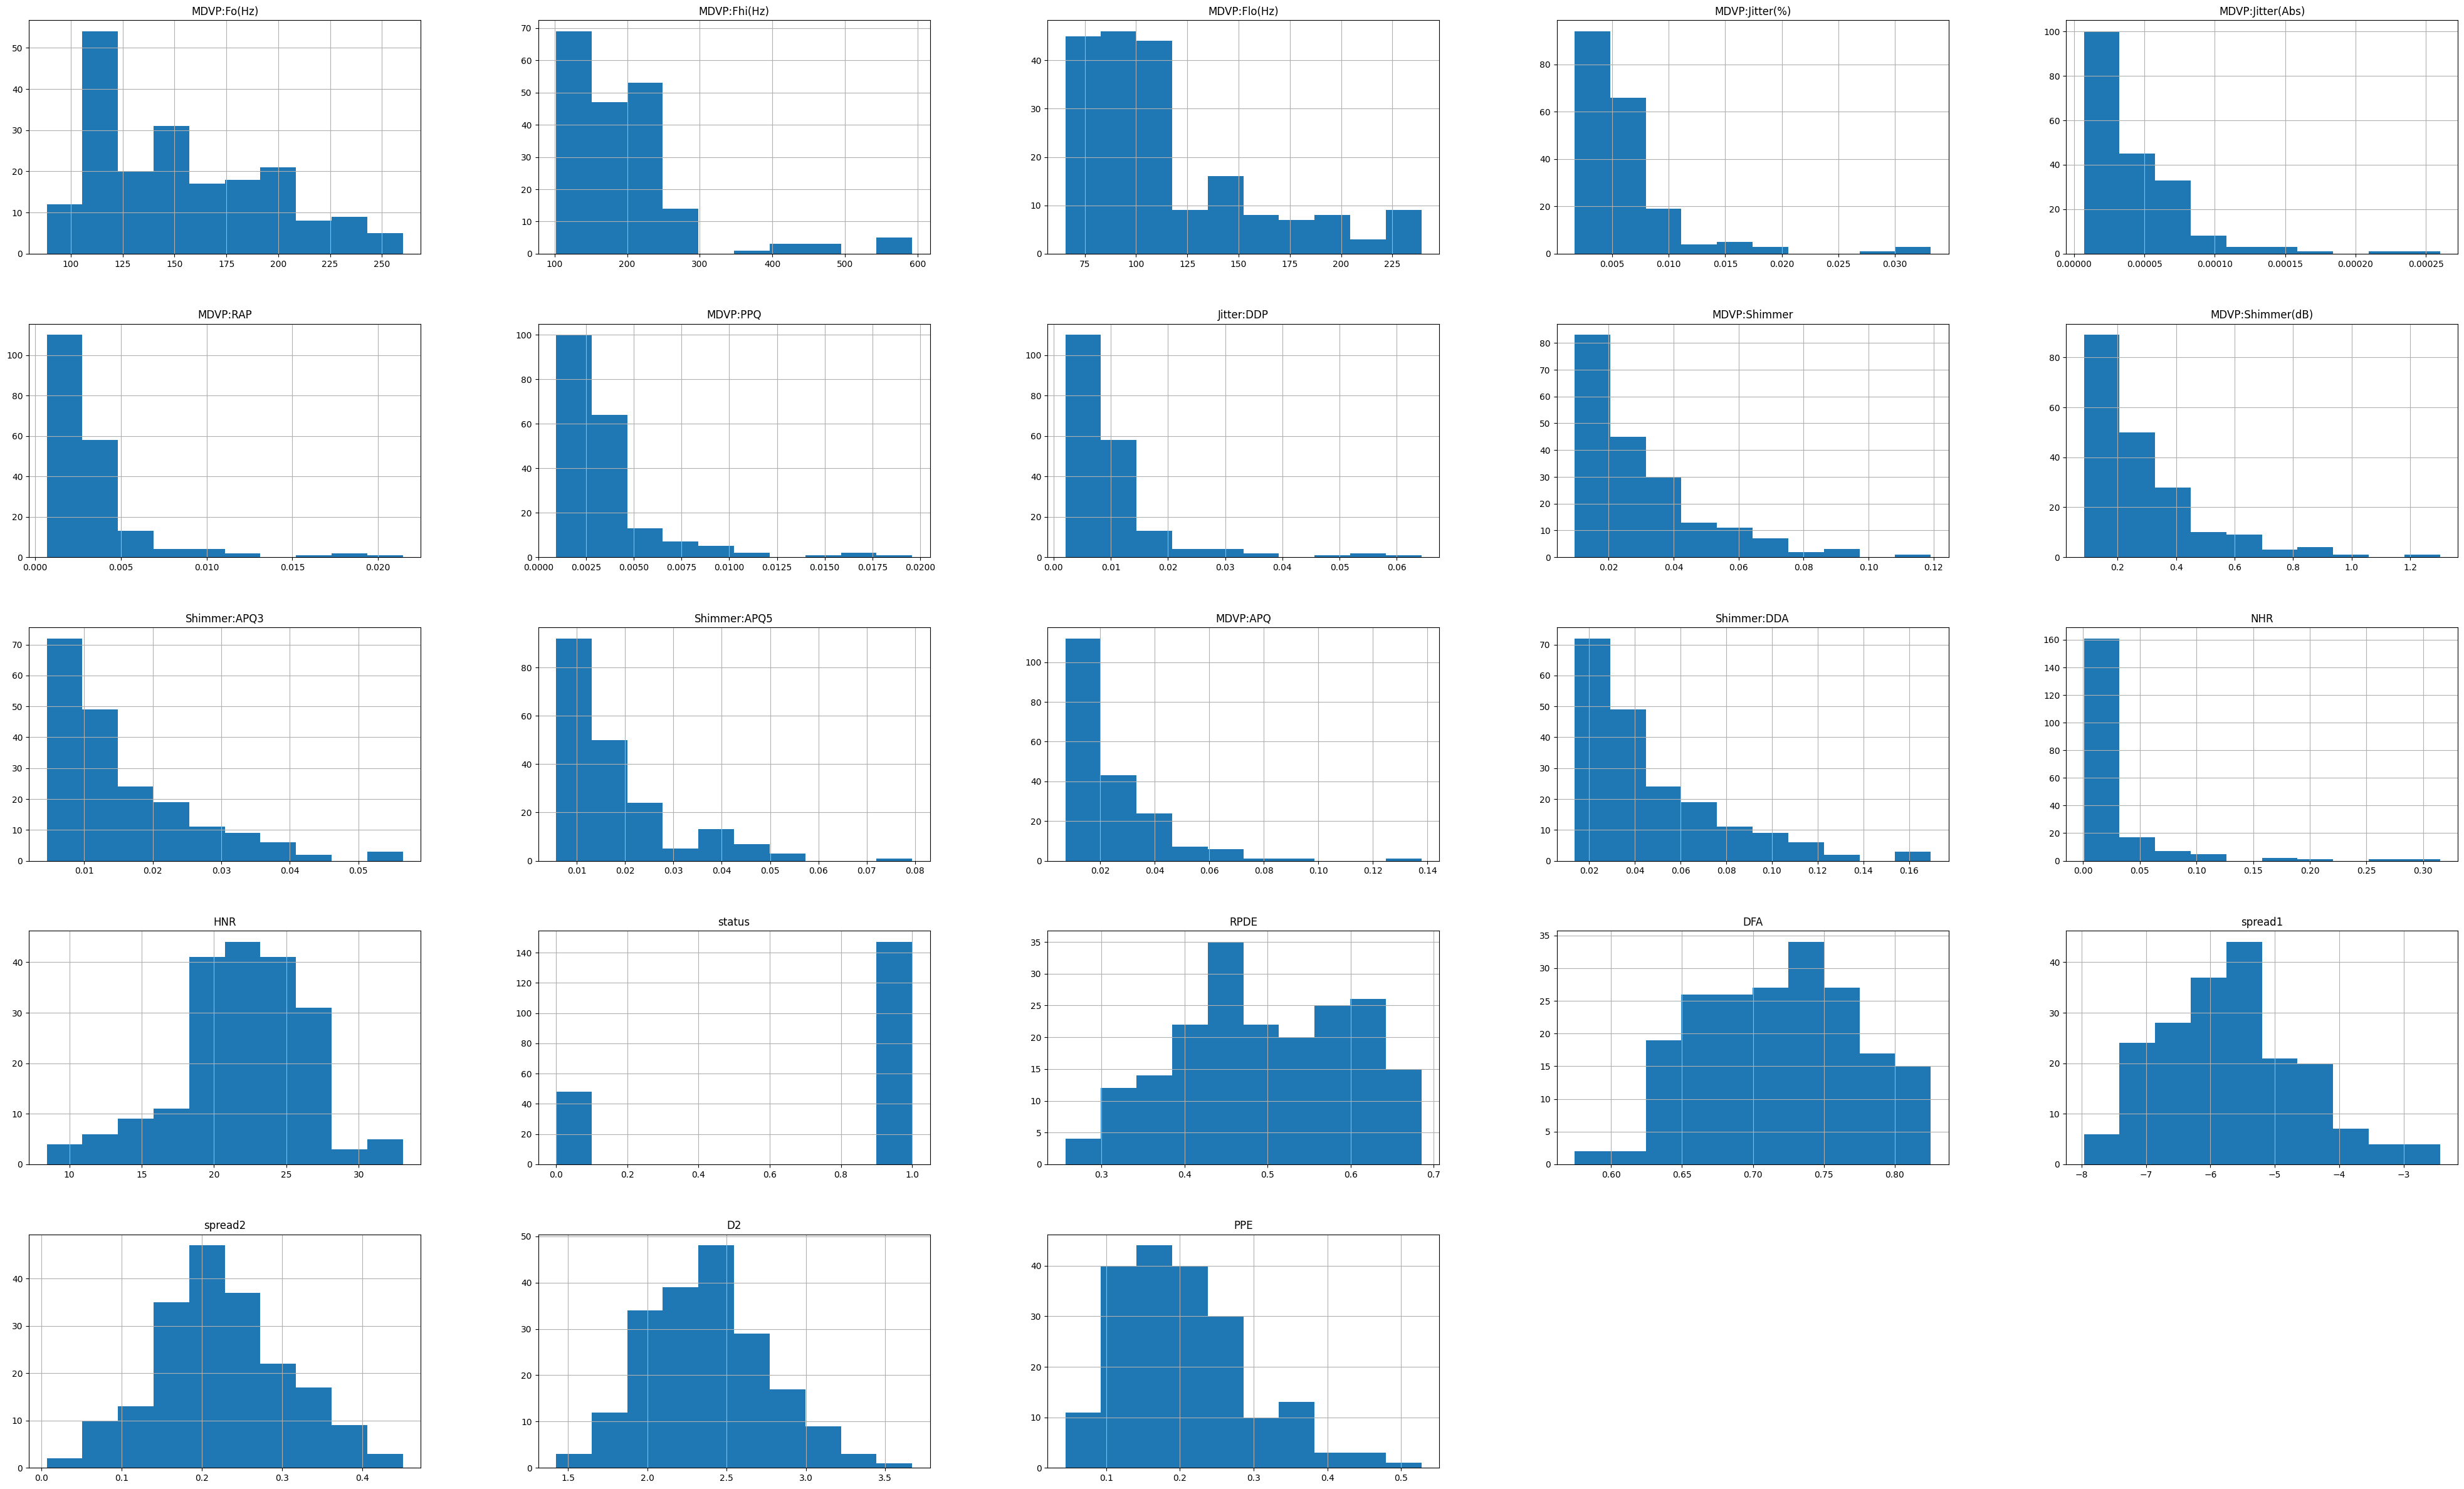

In [8]:
# CODE 4: Visualising distributions and relationships.

# Check outcome/target distribution
target_col = "status"  # <-- Change this based on dataset
sns.countplot(x=data[target_col])
plt.title("Target Variable Distribution")
plt.show()

# Check correlations between variables

if len(numeric_data.columns) > 1:  # Need at least 2 numeric columns for correlation
    plt.figure(figsize=(10, 6))
    sns.heatmap(numeric_data.corr(), annot=False, cmap="coolwarm", center=0)
    plt.title("Correlation Heatmap")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numeric columns for correlation heatmap")

# Plot distribution of features
data.hist(figsize=(50,30))
plt.show()

In [9]:
# CODE 5: SIMPLE MISSING VALUE HANDLING

# In many biomedical datasets, some entries may be missing.
# Example: A patient might not remember their BMI or glucose value,
# or a lab machine may fail to measure a variable.

# Machine learning models cannot work with missing values, so we fill them.

# STRATEGY OR HOW:
# - For numeric columns (e.g., age, BMI, glucose): fill missing values with the median.
#       Why median? Because it is robust to outliers. A few very large or very small
#       values will not distort the median as much as the mean.

# - For categorical columns (e.g., gender, ever_married, smoking_status):
#       fill missing values with the most frequent category (called the "mode").
#       This ensures we replace missing entries with the most common option.


# 1. Identify numeric columns in the dataset

# select_dtypes(include=[np.number]) returns only columns with numeric types 
# (integers, floats).
# .columns gives the column names.
# .tolist() converts the column index into a normal Python list.
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()


# 2. Identify categorical columns

# We use exclude=[np.number] to select all columns that are NOT numeric.
# These columns usually contain text/labels.
categorical_cols = data.select_dtypes(exclude=[np.number]).columns.tolist()


# 3. Fill missing values in numeric columns

# The loop goes through each numeric column name in numeric_cols:
#   - data[col] refers to the column itself.
#   - .fillna(...) replaces all missing values in that column.
#   - data[col].median() calculates the median of that column.
#   - We assign the result back to data[col] to update the dataset.
for col in numeric_cols:
    data[col] = data[col].fillna(data[col].median())


# 4. Fill missing values in categorical columns

# - data[col].mode() returns the most frequent value(s) in that column.
# - .mode() returns a series; mode()[0] picks the first item.
# - This fills missing values with the most common category.
for col in categorical_cols:
    data[col] = data[col].fillna(data[col].mode()[0])

# 5. Verify missing values have been handled

# data.isna().sum() counts how many missing values remain in each column.
print("\nMissing values after filling:")
print(data.isna().sum())

# NB
# numerical_data = data[numeric_cols] # Create a dataframe for columns containing numeric data
# print("Numerical Data")
# numerical_data


Missing values after filling:
name                0
MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64


In [10]:
# This will drop some rows in your dataset and leave a small dataset for # you to use in your analysis

# So basically is to reduce your dataset
 
# new_data = pd.read_csv("parkinsons.csv")
 
# Random sample of 2000 rows

# data_small = new_data.sample(n=50, random_state=42)
 
# data_small.to_csv("parkinsons1.csv", index=False)
 
# data_small.shape

In [11]:
# CODE 6: FEATURE ENGINEERING (PARKINSON VOICE FEATURES)

# IMPORTANT NOTE:
# The columns in this dataset are already "engineered" acoustic features such as:
#   - MDVP:Fo(Hz), MDVP:Fhi(Hz), MDVP:Flo(Hz): various frequency measures
#   - MDVP:Jitter, MDVP:RAP, etc.: measures of pitch instability ("jitter")
#   - MDVP:Shimmer, Shimmer(dB), etc.: measures of loudness instability ("shimmer")
#   - NHR, HNR: noise-to-harmonics and harmonics-to-noise ratios
#   - RPDE, DFA, spread1, spread2, PPE: non-linear dynamic complexity measures

# - use these features directly,
# - and/or group or select the strongest ones (jitter, shimmer, NHR, RPDE, PPE).

# 1. mean_jitter: average of all jitter-related columns
# 2. mean_shimmer: average of all shimmer-related columns
# 3. hnr_to_noise_ratio: HNR divided by (NHR + small constant)
#
# These help us summarise related acoustic measures into simple indices.
# Do not replace the original columns; they just add extra "summary" features.

# Define groups of jitter and shimmer columns

# We build Python lists of column names that belong to "jitter" and "shimmer" families.
# We check that each column exists in the data before using it (to avoid errors).

jitter_cols = [col for col in data.columns if "Jitter" in col or "jitter" in col]
shimmer_cols = [col for col in data.columns if "Shimmer" in col or "shimmer" in col]

print("\nJitter-related columns:", jitter_cols)
print("Shimmer-related columns:", shimmer_cols)

#  Create mean_jitter and mean_shimmer

# .mean(axis=1) calculates the mean across columns (for each row/patient).
# axis=1 means "across columns", axis=0 would mean "down rows".

if len(jitter_cols) > 0:
    data["mean_jitter"] = data[jitter_cols].mean(axis=1)

if len(shimmer_cols) > 0:
    data["mean_shimmer"] = data[shimmer_cols].mean(axis=1)

# Create HNR-to-noise ratio

# NHR = Noise-to-Harmonics Ratio
# HNR = Harmonics-to-Noise Ratio
# Their relationship is clinically interesting because it reflects voice breathiness/stability.
# We build a simple ratio: HNR / (NHR + tiny_constant) to avoid division by zero.

if "HNR" in data.columns and "NHR" in data.columns:
    data["hnr_to_noise_ratio"] = data["HNR"] / (data["NHR"] + 1e-6)

print("\nColumns after feature engineering:")
print(data.columns)


Jitter-related columns: ['MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'Jitter:DDP']
Shimmer-related columns: ['MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5', 'Shimmer:DDA']

Columns after feature engineering:
Index(['name', 'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'status', 'RPDE', 'DFA',
       'spread1', 'spread2', 'D2', 'PPE', 'mean_jitter', 'mean_shimmer',
       'hnr_to_noise_ratio'],
      dtype='object')


In [12]:
# ONE-HOT ENCODING FOR CATEGORICAL VARIABLES

# Machine learning models generally need numbers, not text.
# Columns like "gender", "work_type", "Residence_type", "smoking_status",
# "bmi_category", and "age_group" are categorical.
#
# pd.get_dummies(..., drop_first=True) converts these into dummy/indicator variables:
# Example:
#   gender: ["Male", "Female"]
# becomes columns like:
#   gender_Male (1 if Male, 0 if Female)
# drop_first=True drops one category to avoid redundancy.

# stroke_encoded = pd.get_dummies(stroke, drop_first=True)

# print("\nShape after one-hot encoding:", stroke_encoded.shape)
# print("Example of columns after encoding:")
# print(stroke_encoded.columns[:20])

In [13]:
data.head()

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,status,RPDE,DFA,spread1,spread2,D2,PPE,mean_jitter,mean_shimmer,hnr_to_noise_ratio
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,0.006333,0.117662,951.245986
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,0.007900,0.171578,989.321445
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,0.008973,0.136636,1577.495990
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,0.008370,0.145784,1525.681768
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,0.010870,0.167220,1111.934808


In [14]:
data.shape

(195, 27)

In [15]:
data = data.drop('name', axis=1) # Drop name column

In [16]:
data.shape

(195, 26)

In [17]:
data.head()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,status,RPDE,DFA,spread1,spread2,D2,PPE,mean_jitter,mean_shimmer,hnr_to_noise_ratio
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,0.006333,0.117662,951.245986
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,0.007900,0.171578,989.321445
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,0.008973,0.136636,1577.495990
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,0.008370,0.145784,1525.681768
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,0.010870,0.167220,1111.934808


In [18]:
data.tail()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,status,RPDE,DFA,spread1,spread2,D2,PPE,mean_jitter,mean_shimmer,hnr_to_noise_ratio
190,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,0.405,...,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050,0.004173,0.112858,706.088781
191,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,0.263,...,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895,0.005203,0.074248,1057.786863
192,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,0.256,...,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728,0.010803,0.068690,166.895316
193,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,0.241,...,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306,0.006177,0.065552,263.321842
194,214.289,260.277,77.973,0.00567,0.00003,0.00295,0.00317,0.00885,0.01884,0.190,...,0,0.462803,0.664357,-5.724056,0.190667,2.555477,0.148569,0.004850,0.052298,482.230963


In [19]:
# 7. DEFINE FEATURES (X) AND TARGET (y)

# Now we separate our data into:
#   - X: input features (all columns used to predict)
#   - y: the target we want to predict (Seizure_Binary)

target_col = "status"
# This is the name of the column that contains our binary labels.

X = data.drop(columns=[target_col])
# X is the DataFrame of features.
# .drop(columns=[target_col]) removes the Seizure_Binary column from ep,
# because we don't want to use the label as an input feature.

y = data[target_col]
# y is a Series containing just the target labels (0 or 1) for each row.

print("\nShape of X (features):", X.shape)
print("Shape of y (labels):", y.shape)
# This shows how many samples and features we have in X,
# and how many labels we have in y.


Shape of X (features): (195, 25)
Shape of y (labels): (195,)


In [20]:
# 8. TRAIN–TEST SPLIT

# We split the data into:
#   - training set: used to train the models
#   - test set: used to evaluate the trained models
#
# test_size=0.2 means 20% of the data will be used as the test set.
# random_state=42 means we fix the random seed so that the split is reproducible.
# stratify=y means we preserve the proportion of 0 vs 1 in both train and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set X shape:", X_train.shape)
print("Test set X shape    :", X_test.shape)
print("\nTraining labels distribution:")
print(y_train.value_counts())
print("\nTest labels distribution:")
print(y_test.value_counts())
# value_counts() helps us confirm the class balance in both sets.

Training set X shape: (156, 25)
Test set X shape    : (39, 25)

Training labels distribution:
status
1    118
0     38
Name: count, dtype: int64

Test labels distribution:
status
1    29
0    10
Name: count, dtype: int64


In [21]:
# 9. FEATURE SCALING (STANDARDIZATION)

# Many models and PCA work better if features are on a similar scale.
# For example, Signal_Energy might have values in the thousands,
# while entropy may be between 0 and 1.
# StandardScaler transforms each feature so that:
#   - mean ≈ 0
#   - standard deviation ≈ 1

scaler = StandardScaler()
# We create an instance of StandardScaler. This object will "learn" the statistics
# of the training data and then use them to transform both training and test data.

X_train_scaled = scaler.fit_transform(X_train)
# .fit_transform(X_train) does TWO things:
#   1) fit: it computes the mean and standard deviation for each feature in X_train.
#   2) transform: it uses those statistics to standardize X_train.
# The result is a NumPy array where each column is standardized.

X_test_scaled = scaler.transform(X_test)
# .transform(X_test) applies the previously learned means and stds to X_test.
# We do NOT call fit again on X_test, to avoid "data leakage".

print("\nExample: first 5 original feature values (first row):")
print(X_train.iloc[0, :5].values)
print("After scaling (first row, same 5 features):")
print(X_train_scaled[0, :5])
# This shows how raw values change after standardization.


Example: first 5 original feature values (first row):
[1.10739e+02 1.13597e+02 1.00139e+02 3.56000e-03 3.00000e-05]
After scaling (first row, same 5 features):
[-1.06344643 -0.9157626  -0.33580464 -0.55736615 -0.42216914]


In [22]:
X_train_scaled

array([[-1.06344643, -0.9157626 , -0.33580464, ..., -0.5507314 ,
        -0.79117472,  0.42255683],
       [ 0.58342091,  0.12149404, -0.93052313, ...,  0.21383908,
         0.74631182, -0.51763736],
       [-1.07057001, -0.75769779, -0.20592359, ..., -0.30843794,
         0.44452628, -0.44676943],
       ...,
       [-0.8255786 , -0.75169732, -0.33412566, ..., -0.25796013,
        -0.83394188, -0.32171323],
       [ 1.21627388,  0.18966471,  1.98934195, ..., -0.82674404,
        -1.03317859,  6.64262457],
       [-0.82640055, -0.78369603, -0.22465621, ..., -0.40804747,
        -0.78169064, -0.15086519]], shape=(156, 25))

In [23]:
X_train_scaled.shape

(156, 25)

In [24]:
X_test_scaled

array([[-9.25283827e-01, -1.97353846e-01, -4.11502626e-01,
        -6.37814292e-01, -4.22169138e-01, -6.57852431e-01,
        -5.60668451e-01, -6.56879888e-01, -7.67569921e-01,
        -7.67383846e-01, -8.98835308e-01, -6.89242167e-01,
        -4.62519776e-01, -8.98847061e-01, -4.37227224e-01,
         5.45728155e-01,  9.48137835e-01, -1.17636793e+00,
         8.02527058e-02, -1.14998931e+00, -8.36752543e-01,
         5.27139824e-02, -6.51013973e-01, -7.88581691e-01,
        -3.64976202e-02],
       [-1.06770563e+00, -7.82703473e-01, -1.75534066e-01,
        -3.54330359e-01, -1.50363997e-01, -3.71312277e-01,
        -2.64225049e-01, -3.72425149e-01, -4.49751660e-01,
        -4.73677347e-01, -3.24044117e-01, -5.23611904e-01,
        -4.92739008e-01, -3.24048354e-01, -5.09251263e-01,
         8.97345072e-01, -6.92135103e-01,  1.77260962e+00,
         2.67853045e-01,  2.96680425e-01, -1.53733677e+00,
         2.55960647e-01, -3.66319155e-01, -4.54259001e-01,
         4.18295487e-01],
    

In [25]:
X_test_scaled.shape

(39, 25)


Explained variance ratio by PC1 and PC2:
[0.60099146 0.10206229]
Total variance explained by the first 2 PCs: 0.7030537437451503


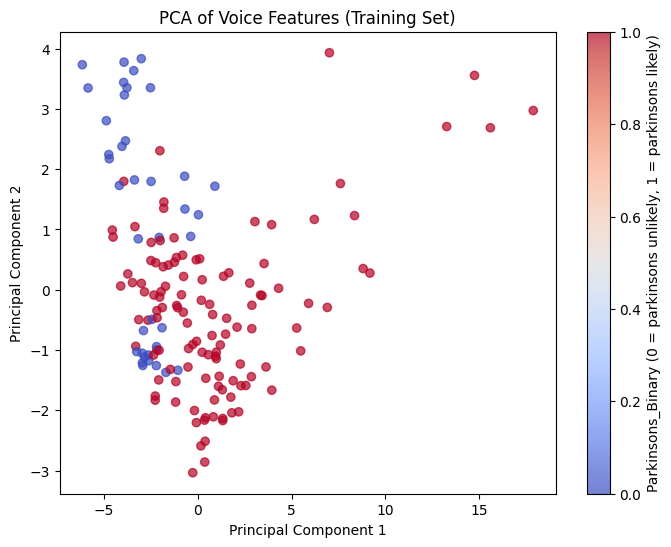

In [27]:
# 10. PCA VISUALISATION (OPTIONAL EDA)

# Here we use PCA only to visualize the data in 2 dimensions.
# This does NOT affect the model training; it is just for understanding.

pca = PCA(n_components=2)
# n_components=2 means we want to reduce the data to 2 principal components (PC1 and PC2).

X_train_pca = pca.fit_transform(X_train_scaled)
# .fit_transform(X_train_scaled):
#   - learns the principal components from the training data
#   - projects the training data into a new coordinate system with just 2 axes (PC1, PC2).

print("\nExplained variance ratio by PC1 and PC2:")
print(pca.explained_variance_ratio_)
# explained_variance_ratio_ is an array where:
#   element 0 = fraction of total variance explained by PC1
#   element 1 = fraction of total variance explained by PC2

print("Total variance explained by the first 2 PCs:",
      pca.explained_variance_ratio_.sum())

# Now we create a scatter plot of PC1 vs PC2,
# colouring each point by its label (0 = non-seizure, 1 = seizure).
plt.figure(figsize=(8, 6))
plt.scatter(
    X_train_pca[:, 0],   # x-axis: values of PC1
    X_train_pca[:, 1],   # y-axis: values of PC2
    c=y_train,           # colour: 0 or 1 (non-seizure vs seizure)
    cmap="coolwarm",     # coolwarm colormap: one colour for 0, another for 1
    alpha=0.7            # alpha < 1 means points are slightly transparent
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Voice Features (Training Set)")
plt.colorbar(label="Parkinsons_Binary (0 = parkinsons unlikely, 1 = parkinsons likely)")
plt.show()

# Interpretation:
#   - Each dot is one parkinsons prediction.
#   - The position of the dot is based on all features combined, compressed into PC1 and PC2.
#   - If red and blue dots cluster separately, the classes may be easier to separate.
#   - If they overlap strongly, the problem is more challenging.

In [28]:
# 11. HANDLE CLASS IMBALANCE WITH SMOTE

# In many medical datasets, one class is much more common than the other.
# For parkinson's disease:
#   - Diseased classes (1) are often much more frequent than healthy classes (0).

# If we train a model on imbalanced data without correction:
#   - It might always predict the majority class (1) and still get "high accuracy".
#   - But it would miss healthy predictions, which is clinically unacceptable.

# SMOTE (Synthetic Minority Oversampling Technique) addresses this by
# generating synthetic examples of the minority class in the feature space.

print("\nClass distribution BEFORE SMOTE (training set):")
print(y_train.value_counts())
# This shows how many 0 and 1 labels are in the training set before balancing.

smote = SMOTE(random_state=42)
# We create an instance of SMOTE.
# random_state=42 is for reproducibility (same synthetic examples each run).

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)
# .fit_resample(X_train_scaled, y_train) does the following:
#   - looks at how many samples belong to each class
#   - for the minority class, it synthesizes new examples by interpolating
#     between existing minority samples in feature space.
#   - returns new balanced arrays X_train_balanced and y_train_balanced
# where classes 0 and 1 have the same number of samples.

print("\nClass distribution AFTER SMOTE (training set):")
print(y_train_balanced.value_counts())
# Now we should see equal counts of 0 and 1 in the training set.


Class distribution BEFORE SMOTE (training set):
status
1    118
0     38
Name: count, dtype: int64

Class distribution AFTER SMOTE (training set):
status
0    118
1    118
Name: count, dtype: int64


In [29]:
X_train_balanced.shape

(236, 25)

In [30]:
y_train_balanced.shape

(236,)

In [33]:
# 12. DEFINE MULTIPLE CLASSIFICATION MODELS

# We want to compare several different machine learning models:
#   - Logistic Regression
#   - Random Forest
#   - Gradient Boosting
#   - SVM (with RBF kernel)

# By defining them in a dictionary, we can later loop through them
# and train/evaluate each one in a compact way.

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,        # allow up to 1000 iterations for convergence
        class_weight="balanced"  # penalize mistakes on minority class more
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,     # number of decision trees in the forest
        random_state=42,      # seed for reproducibility
        class_weight="balanced"  # handle imbalance inside the model too
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42       # seed for reproducibility
    ),
    "SVM (RBF)": SVC(
        kernel="rbf",         # RBF (radial basis function) kernel for non-linear boundaries
        probability=True,     # enable probability estimates (needed for ROC-AUC)
        class_weight="balanced",  # handle class imbalance in the SVM loss
        random_state=42
    )
}

print("\nModels defined:")
for name in models.keys():
    print("-", name)
# This loop simply prints the names of all models we will train.


Models defined:
- Logistic Regression
- Random Forest
- Gradient Boosting
- SVM (RBF)


In [41]:
# 13. TRAIN AND EVALUATE ALL MODELS

# Now we:
#   - loop over each model in the models dictionary
#   - train it on the balanced training set (X_train_balanced, y_train_balanced)
#   - evaluate it on the original test set (X_test_scaled)
#   - compute accuracy, F1-score, and ROC-AUC
#   - store these metrics in a dictionary for comparison

results = {}          # dictionary to store metrics for each model
y_pred_store = {}     # dictionary to store class predictions for each model
y_prob_store = {}     # dictionary to store predicted probabilities for each model

for name, model in models.items():
    # name: string with model name (e.g., "Random Forest")
    # model: the actual model object (e.g., RandomForestClassifier instance)
    
    print(f"\nTraining {name}...")
    model.fit(X_train_balanced, y_train_balanced)
    # .fit(features, labels) trains the model.
    # The model learns a mapping from X_train_balanced → y_train_balanced.

    y_pred = model.predict(X_test_scaled)
    # .predict(X_test_scaled) uses the trained model to assign a class (0 or 1)
    # to each sample in the test set.
    
    if hasattr(model, "predict_proba"):
        # Some models (e.g., Logistic Regression, Random Forest, SVM with probability=True)
        # provide a method .predict_proba() that returns probabilities.
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        # .predict_proba(X_test_scaled) returns an array of shape (n_samples, 2):
        #   [:, 0] is the probability of class 0
        #   [:, 1] is the probability of class 1 (seizure)
        # We take [:, 1] because we need the probability of the positive class.
    else:
        y_prob = None
        # If the model does not support predict_proba(), we leave y_prob as None.

    # Compute metrics:
    acc = accuracy_score(y_test, y_pred)
    # accuracy_score compares y_test (true labels) with y_pred (predicted labels)
    # and calculates the fraction that are equal.

    f1 = f1_score(y_test, y_pred)
    # f1_score combines precision and recall into a single number.
    # It is very useful when classes are imbalanced.

    roc = roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    # roc_auc_score needs the true labels and the predicted probabilities for class 1.
    # If y_prob is None (no probabilities), we store NaN (not a number) for ROC-AUC.

    results[name] = {
        "accuracy": acc,
        "f1": f1,
        "roc_auc": roc
    }
    # Store the metrics for this model in the results dictionary.

    y_pred_store[name] = y_pred
    # Save the predicted labels for later inspection if needed.

    y_prob_store[name] = y_prob
    # Save the predicted probabilities (if available).

# Convert results into a DataFrame so it's easier to read and sort.
results_df = pd.DataFrame(results).T.sort_values("f1", ascending=False)
# pd.DataFrame(results) converts the dictionary into a DataFrame.
# .T transposes rows and columns so models are rows and metrics are columns.
# .sort_values("f1", ascending=False) sorts models by F1-score from best to worst.

print("\n=== MODEL PERFORMANCE ON TEST SET (Binary Parkinson's Disease Prediction) ===")
print(results_df)


Training Logistic Regression...

Training Random Forest...

Training Gradient Boosting...

Training SVM (RBF)...

=== MODEL PERFORMANCE ON TEST SET (Binary Parkinson's Disease Prediction) ===
                     accuracy        f1   roc_auc
Gradient Boosting    0.948718  0.964286  0.982759
Random Forest        0.897436  0.928571  0.965517
SVM (RBF)            0.846154  0.884615  0.937931
Logistic Regression  0.743590  0.807692  0.920690


In [47]:
# 14. SELECT THE BEST MODEL AND PRINT A DETAILED REPORT

# We choose the model with the highest F1-score, because F1 is more
# informative than accuracy in imbalanced datasets.

best_model_name = results_df["f1"].idxmax()
# .idxmax() returns the index label (here: model name) of the row where "f1" is maximum.

best_model = models[best_model_name]
# Retrieve the best model object from the models dictionary.

print(f"\nBest model (based on F1-score): {best_model_name}")

# Retrieve predictions and probabilities for the best model:
y_pred_best = y_pred_store[best_model_name]
# y_prob_best = y_prob_store[best_model_name]

print("\n=== CLASSIFICATION REPORT FOR BEST MODEL ===")
print(classification_report(y_test, y_pred_best))
# classification_report prints:
#   - precision (of class 0 and 1)
#   - recall (of class 0 and 1)
#   - F1-score (of class 0 and 1)
#   - support (how many samples of each class are in y_test)

# if y_prob_best is not None:
    # roc_best = roc_auc_score(y_test, y_prob_best)
    # print("ROC-AUC for best model:", roc_best)
    # This shows how well the best model ranks parkinson's likely vs parkinson's unlikely samples.


Best model (based on F1-score): Gradient Boosting

=== CLASSIFICATION REPORT FOR BEST MODEL ===
              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       1.00      0.93      0.96        29

    accuracy                           0.95        39
   macro avg       0.92      0.97      0.94        39
weighted avg       0.96      0.95      0.95        39




Top 15 most important features according to the best model:
spread1         0.335728
PPE             0.156432
MDVP:Fhi(Hz)    0.083921
MDVP:Flo(Hz)    0.061506
MDVP:Fo(Hz)     0.049127
MDVP:RAP        0.040860
spread2         0.040505
MDVP:APQ        0.034160
Jitter:DDP      0.033432
RPDE            0.032989
DFA             0.023981
D2              0.020276
NHR             0.018432
Shimmer:DDA     0.013936
MDVP:Shimmer    0.013729
dtype: float64


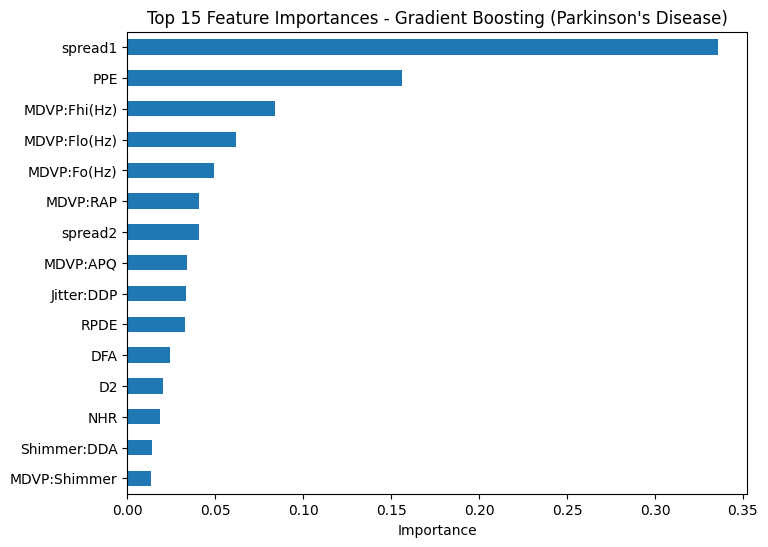

In [48]:
# 15. FEATURE IMPORTANCE

# Some models, like RandomForestClassifier and GradientBoostingClassifier,
# have an attribute called .feature_importances_.
# This tells us how important each feature was in making predictions.
# This is extremely valuable in biomedical settings, where we want to know:
#   "Which EEG features matter most for detecting seizures?"

if hasattr(best_model, "feature_importances_"):
    # hasattr(object, "attribute_name") checks if the object has that attribute.
    importances = pd.Series(
        best_model.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)
    # best_model.feature_importances_ is an array with one importance value per feature.
    # We convert it into a pandas Series for easier manipulation, tagging each importance
    # with the corresponding feature name (index=X.columns).
    # .sort_values(ascending=False) sorts features from most to least important.

    print("\nTop 15 most important features according to the best model:")
    print(importances.head(15))
    # .head(15) shows the top 15 features only.

    # Plot the feature importances for visual interpretation.
    plt.figure(figsize=(8, 6))
    importances.head(15).plot(kind="barh")
    # .plot(kind="barh") creates a horizontal bar chart.

    plt.gca().invert_yaxis()
    # invert_yaxis() flips the y-axis so the most important feature appears on top.

    plt.xlabel("Importance")
    plt.title(f"Top 15 Feature Importances - {best_model_name} (Parkinson's Disease)")
    plt.show()
else:
    print(f"\nThe best model ({best_model_name}) does not provide feature_importances_.")
    print("For such models (e.g., SVM), you can use model-agnostic tools like SHAP or LIME")
    print("to understand which features contribute most to each individual prediction.")

In [49]:
# 16. SAVE THE TRAINED MODEL AND SCALER TO DISK (DEPLOYMENT STEP)

# Once we have trained a good model, we often want to:
#   - reuse it later without retraining
#   - load it in a web app (e.g., Streamlit, Flask, Django)
#   - share it with others
#
# To do this, we "serialize" the model and scaler:
#   - Serialization = convert Python objects (model, scaler) into a file
#   - Later we can "deserialize" (load) the objects back into Python.
#
# We will use a library called joblib for this.
# joblib is commonly used to save scikit-learn models.

import joblib
# joblib provides two main functions:
#   - joblib.dump(object, filename)   → save object to file
#   - joblib.load(filename)           → load object back from file



# 16.1 Define filenames for saving

# We choose clear, descriptive filenames so that:
#   - it’s obvious which file is the model
#   - it’s obvious which file is the scaler

model_filename = "best_parkinsons_model.joblib"
# This string is the name of the file where we will save the best model.
# It will create a file in the current working directory.

scaler_filename = "parkinsons_scaler.joblib"
# This string is the name of the file where we will save the StandardScaler.

# 16.2 Save the best model to disk

# best_model is the model object we selected earlier (based on F1-score).
# joblib.dump(object, filename) writes the object into a file.
# After this, we no longer need to retrain to use this model again.

joblib.dump(best_model, model_filename)
print(f"\nSaved best model to file: {model_filename}")



# 16.3 Save the fitted scaler to disk

# scaler is the StandardScaler that was fitted on the training data.
# It knows the mean and standard deviation for each feature.
# When we get NEW patient data, we must:
#   - load this same scaler
#   - call scaler.transform(new_data) before sending it to the model
#
# If we do not use the same scaler, the model will receive wrongly scaled values
# and performance will be poor or unpredictable.

joblib.dump(scaler, scaler_filename)
print(f"Saved scaler to file: {scaler_filename}")



# 16.4 How to load these later

# The code below is just an example of how you would load the model and scaler
# in a different script or notebook (e.g., inside a Streamlit app).
# You DON'T need to run this now; it's documentation for deployment.

# Example:
# loaded_model = joblib.load("best_epilepsy_model.joblib")
# loaded_scaler = joblib.load("epilepsy_scaler.joblib")
#
# Then, given a new sample X_new (with same columns as X):
#   - X_new_scaled = loaded_scaler.transform(X_new)
#   - y_new_pred   = loaded_model.predict(X_new_scaled)
#
# This is exactly how you would use the trained epilepsy detector
# on new EEG feature data in a deployment setting.


Saved best model to file: best_parkinsons_model.joblib
Saved scaler to file: parkinsons_scaler.joblib
